# Portfolio Analysis: Where Lending Club Bleeds Money

A deep look at default patterns across grades, purposes, geographies, and vintages — to find the segments most underpriced by the grade-based system.

| | |
|---|---|
| **Notebook** | 02 of 05 |
| **Previous** | `01_business_context.ipynb` |
| **Next** | `03_feature_engineering.ipynb` |

---

## What this notebook does

Notebook 01 set the stage: 297K terminal loans, 20% default rate, $662M lost. This notebook digs into *why*. The grade system (A through G) is the headline pricing tool, but it hides as much as it reveals. The goal here is to surface the segments where the grade alone doesn't tell the full risk story — the segments a model should be able to price more accurately.

## Sections

| # | Focus |
|---|---|
| 1 | Setup and data load |
| 2 | Default rate by grade and sub-grade |
| 3 | Default rate by loan purpose |
| 4 | Default rate by US state |
| 5 | Vintage analysis: how default behavior shifted 2008–2018 |
| 6 | Borrower profile: income, DTI, and loan size |
| 7 | The mispricing finding — where the grade fails |
| 8 | Missing value audit and column-drop justification |
| 9 | Handoff to notebook 03 |

## 1. Setup and data load

Each notebook in this project is self-contained — re-loading the data from the raw CSV instead of importing from a previous notebook. That makes every notebook openable and runnable on its own, which matters for anyone reading on GitHub.

Same 500K random sample as notebook 01, same seed, so the numbers stay consistent across the project.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Imports and display configuration
# ─────────────────────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

os.makedirs('outputs', exist_ok=True)

PALETTE = {
    'bg':      '#0f1117',
    'panel':   '#1a1d29',
    'text':    '#e8eaed',
    'muted':   '#8b8fa3',
    'primary': '#4c9aff',
    'success': '#36b37e',
    'danger':  '#ff5630',
    'warn':    '#ffab00',
    'accent':  '#8777d9',
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['bg'],
    'savefig.facecolor': PALETTE['bg'],
    'axes.edgecolor':    PALETTE['muted'],
    'axes.labelcolor':   PALETTE['text'],
    'text.color':        PALETTE['text'],
    'xtick.color':       PALETTE['muted'],
    'ytick.color':       PALETTE['muted'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     18,
    'figure.figsize':    (12, 6),
    'figure.dpi':        110,
})

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Load the same 500K random sample used in notebook 01
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_SIZE = 500_000
SEED        = 42

total_rows = sum(1 for _ in open('accepted_2007_to_2018Q4.csv')) - 1

rng = np.random.default_rng(SEED)
keep_idx = set(rng.choice(total_rows, size=SAMPLE_SIZE, replace=False))
skip_rows = [i + 1 for i in range(total_rows) if i not in keep_idx]

df = pd.read_csv(
    'accepted_2007_to_2018Q4.csv',
    low_memory=False,
    skiprows=skip_rows,
)

# Build the binary default flag for the terminal subset
# Note: portfolio analysis below uses both terminal and active loans depending on the question
df['default'] = np.where(
    df['loan_status'] == 'Charged Off', 1,
    np.where(df['loan_status'] == 'Fully Paid', 0, np.nan)
)

terminal = df[df['default'].notna()].copy()
terminal['default'] = terminal['default'].astype(int)

print(f"Full sample        : {len(df):>10,}  loans")
print(f"Terminal loans     : {len(terminal):>10,}  loans")
print(f"Active / in-flight : {len(df) - len(terminal):>10,}  loans")
print(f"Default rate       : {terminal['default'].mean():>10.1%}")
print(f"Date range         : {df['issue_d'].min()}  to  {df['issue_d'].max()}")

Full sample        :    500,000  loans
Terminal loans     :    297,299  loans
Active / in-flight :    202,701  loans
Default rate       :      20.0%
Date range         : Apr-2008  to  Sep-2018


## 2. Default rate by grade and sub-grade

Lending Club assigns each loan a letter grade A through G, with sub-grades 1 through 5 inside each (A1 is the safest, G5 the riskiest). The grade drives the interest rate. So if the system works well, default rates should rise smoothly as grade gets riskier — and within each grade, sub-grades 1–5 should show a similar smooth gradient.

Two things worth checking:

| Question | Why it matters |
|---|---|
| Does default rate rise monotonically from A to G? | Confirms the grade system is at least directionally correct |
| How wide is the spread *within* each grade? | A wide spread means the grade alone is missing risk signal — exactly the gap a model can exploit |

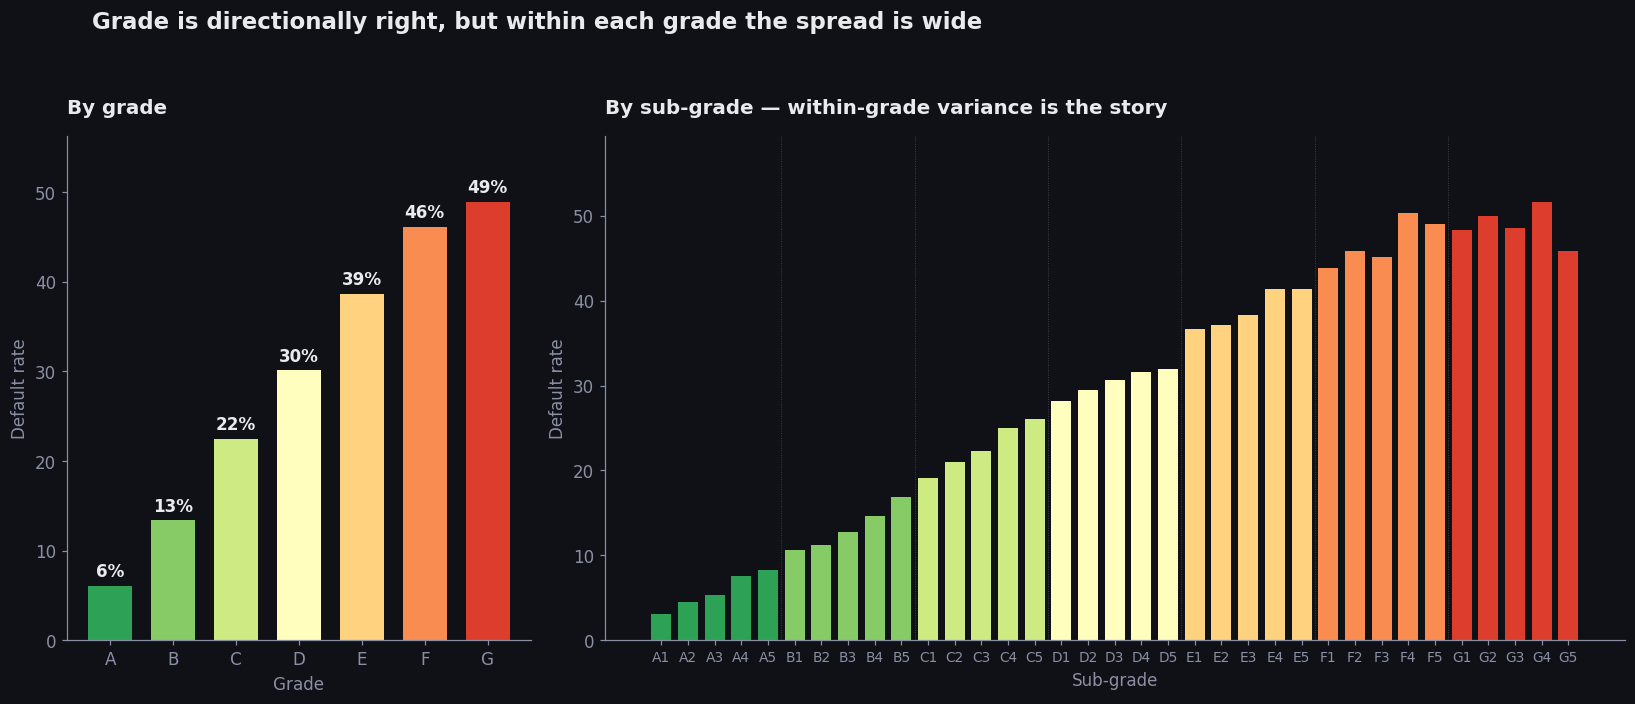


Grade-level default rates and sample sizes:

grade default_rate  loans
    A         6.1% 52,084
    B        13.4% 86,643
    C        22.5% 84,675
    D        30.1% 44,043
    E        38.6% 20,620
    F        46.2%  7,188
    G        48.9%  2,046


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Default rate by grade and sub-grade
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={'width_ratios': [1, 2.2]})

# ─── LEFT PANEL: by grade ────────────────────────────────────────────────────
grade_stats = (
    terminal.groupby('grade')['default']
            .agg(['mean', 'count'])
            .reset_index()
            .sort_values('grade')
)

# Color gradient from green (safe) to red (risky)
grade_colors = sns.color_palette('RdYlGn_r', n_colors=len(grade_stats))

bars1 = ax1.bar(
    grade_stats['grade'],
    grade_stats['mean'] * 100,
    color=grade_colors,
    edgecolor='none',
    width=0.7,
)

for bar, rate, n in zip(bars1, grade_stats['mean'], grade_stats['count']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f'{rate:.0%}',
        ha='center', va='bottom',
        color=PALETTE['text'], fontsize=11, fontweight='600',
    )

ax1.set_xlabel('Grade', color=PALETTE['muted'])
ax1.set_ylabel('Default rate', color=PALETTE['muted'])
ax1.set_ylim(0, grade_stats['mean'].max() * 100 * 1.15)
ax1.set_title('By grade', loc='left', color=PALETTE['text'], fontsize=13, pad=15)
ax1.spines['left'].set_color(PALETTE['muted'])
ax1.spines['bottom'].set_color(PALETTE['muted'])
ax1.tick_params(axis='y', labelcolor=PALETTE['muted'])

# ─── RIGHT PANEL: by sub-grade ───────────────────────────────────────────────
sub_stats = (
    terminal.groupby('sub_grade')['default']
            .agg(['mean', 'count'])
            .reset_index()
            .sort_values('sub_grade')
)

# Map each sub-grade to its parent grade's color
sub_stats['parent'] = sub_stats['sub_grade'].str[0]
parent_color = dict(zip(grade_stats['grade'], grade_colors))
sub_colors = sub_stats['parent'].map(parent_color)

bars2 = ax2.bar(
    sub_stats['sub_grade'],
    sub_stats['mean'] * 100,
    color=sub_colors,
    edgecolor='none',
    width=0.75,
)

ax2.set_xlabel('Sub-grade', color=PALETTE['muted'])
ax2.set_ylabel('Default rate', color=PALETTE['muted'])
ax2.set_ylim(0, sub_stats['mean'].max() * 100 * 1.15)
ax2.set_title('By sub-grade — within-grade variance is the story', loc='left', color=PALETTE['text'], fontsize=13, pad=15)
ax2.tick_params(axis='x', labelsize=9, rotation=0, labelcolor=PALETTE['muted'])
ax2.tick_params(axis='y', labelcolor=PALETTE['muted'])
ax2.spines['left'].set_color(PALETTE['muted'])
ax2.spines['bottom'].set_color(PALETTE['muted'])

# Add subtle dividers between grade groups (after every 5th sub-grade)
for x in [4.5, 9.5, 14.5, 19.5, 24.5, 29.5]:
    ax2.axvline(x=x, color=PALETTE['muted'], linestyle=':', linewidth=0.6, alpha=0.4)

# ─── SUPER-TITLE ─────────────────────────────────────────────────────────────
fig.suptitle(
    'Grade is directionally right, but within each grade the spread is wide',
    x=0.06, y=0.98, ha='left',
    color=PALETTE['text'], fontsize=15, fontweight='bold',
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('outputs/02_default_by_grade.png', dpi=160, bbox_inches='tight')
plt.show()

# ─── SUPPORTING TABLE ────────────────────────────────────────────────────────
print('\nGrade-level default rates and sample sizes:\n')
print(
    grade_stats.assign(
        default_rate=lambda d: (d['mean'] * 100).round(1).astype(str) + '%',
        loans=lambda d: d['count'].map('{:,}'.format),
    )[['grade', 'default_rate', 'loans']]
      .to_string(index=False)
)

> **Three observations from the grade chart:**
>
> 1. **The grade system is directionally correct.** Default rate climbs cleanly from 6% (Grade A) to 49% (Grade G). The risk ordering itself isn't broken.
>
> 2. **Within-grade variance is wide.** Inside Grade C, sub-grade C1 defaults at ~17% while C5 hits ~28% — an 11-point spread despite sharing the same letter grade and similar interest rate band. That spread is the gap a model can close.
>
> 3. **Grade G barely differentiates from F.** F defaults at 46%, G at 49% — only 3 points apart, even though G is supposed to be the riskiest tier. The grade system effectively stops sorting at the bottom of the curve.
>
> Together these point to the same conclusion: the grade is a useful coarse signal, but it leaves real risk information on the table — especially in the middle (B–D, where most of the volume sits) and at the tail (F, G).

## 3. Default rate by loan purpose

Lending Club lets borrowers state the *purpose* of each loan: debt consolidation, credit card refinancing, home improvement, small business, medical, etc. The grade system doesn't directly factor purpose into the price — yet some purposes default at materially higher rates than others.

If a Grade C loan for a small business defaults more often than a Grade C loan for a wedding, but both pay the same interest rate, that's a structural mispricing.

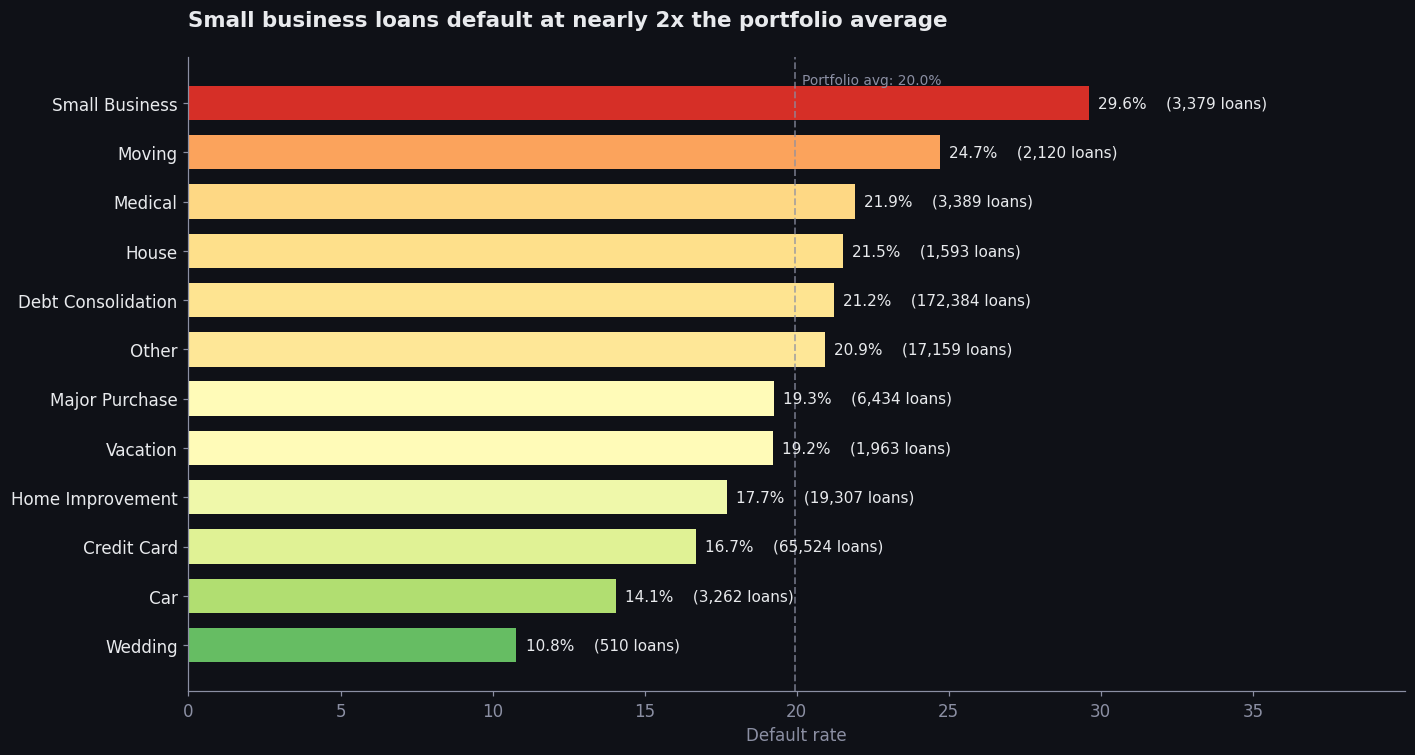

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Default rate by loan purpose
# ─────────────────────────────────────────────────────────────────────────────
purpose_stats = (
    terminal.groupby('purpose')['default']
            .agg(['mean', 'count'])
            .reset_index()
            .sort_values('mean', ascending=True)
)

# Filter out tiny categories (<500 loans) so we don't read noise
purpose_stats = purpose_stats[purpose_stats['count'] >= 500].copy()

# Color: red gradient by default rate
norm = (purpose_stats['mean'] - purpose_stats['mean'].min()) / (
    purpose_stats['mean'].max() - purpose_stats['mean'].min()
)
purpose_colors = [plt.cm.RdYlGn_r(0.2 + 0.7 * v) for v in norm]

# Reference line: portfolio-wide default rate
overall_rate = terminal['default'].mean()

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    purpose_stats['purpose'].str.replace('_', ' ').str.title(),
    purpose_stats['mean'] * 100,
    color=purpose_colors,
    edgecolor='none',
    height=0.7,
)

# Value labels: rate + loan count
for bar, rate, n in zip(bars, purpose_stats['mean'], purpose_stats['count']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{rate:.1%}    ({n:,} loans)',
        va='center', ha='left',
        color=PALETTE['text'], fontsize=10,
    )

# Portfolio-average reference line
ax.axvline(
    x=overall_rate * 100,
    color=PALETTE['muted'],
    linestyle='--', linewidth=1.2, alpha=0.7,
)
ax.text(
    overall_rate * 100 + 0.2, len(purpose_stats) - 0.4,
    f'Portfolio avg: {overall_rate:.1%}',
    color=PALETTE['muted'], fontsize=9, va='top',
)

ax.set_xlim(0, purpose_stats['mean'].max() * 100 * 1.35)
ax.set_xlabel('Default rate', color=PALETTE['muted'])
ax.set_ylabel('')
ax.set_title(
    'Small business loans default at nearly 2x the portfolio average',
    loc='left', color=PALETTE['text'], pad=20,
)
ax.spines['left'].set_color(PALETTE['muted'])
ax.spines['bottom'].set_color(PALETTE['muted'])
ax.tick_params(axis='x', labelcolor=PALETTE['muted'])
ax.tick_params(axis='y', labelcolor=PALETTE['text'])

plt.tight_layout()
plt.savefig('outputs/03_default_by_purpose.png', dpi=160, bbox_inches='tight')
plt.show()

> **Three observations from the purpose chart:**
>
> 1. **Small business loans default at nearly 2x the portfolio average** (29.6% vs 20%). They're the riskiest segment in the entire portfolio — riskier than any letter grade except F and G.
>
> 2. **Debt consolidation dominates volume** (172K loans, 58% of the terminal portfolio) and sits exactly at the portfolio average. It's the median use case, but its sheer size means even small mispricing here moves the bottom line meaningfully.
>
> 3. **The spread is ~3x.** Wedding loans default at 10.8%, small-business loans at 29.6%. That gap rivals the spread *within* the grade system — yet purpose isn't priced in. Two Grade C borrowers paying the same interest rate may carry very different actual risk depending on what they're borrowing for.

## 4. Default rate by US state

State isn't priced into the grade either. But state captures things the grade can't: local economic conditions, cost of living, employment markets, even consumer protection laws. If certain states default systematically more than others, that's another structural mispricing.

The chart below shows the top 15 and bottom 15 states by default rate, filtered to states with at least 1,000 loans so we're not reading noise from tiny markets.

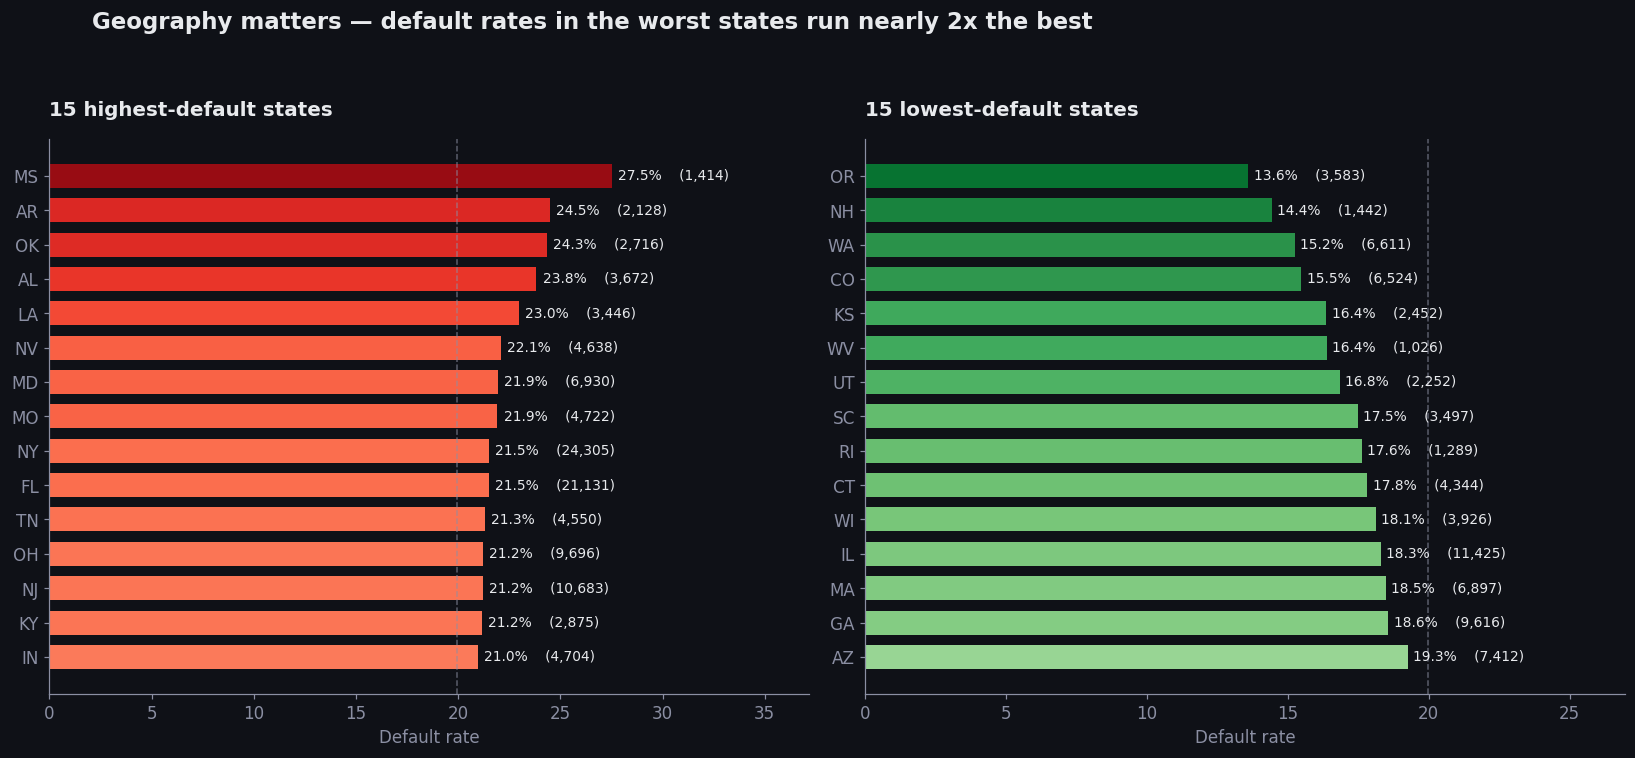

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Default rate by state — top and bottom 15
# ─────────────────────────────────────────────────────────────────────────────
state_stats = (
    terminal.groupby('addr_state')['default']
            .agg(['mean', 'count'])
            .reset_index()
)

# Filter to states with meaningful sample size
state_stats = state_stats[state_stats['count'] >= 1_000].sort_values('mean')

top15    = state_stats.tail(15).sort_values('mean', ascending=True)
bottom15 = state_stats.head(15).sort_values('mean', ascending=False)

overall_rate = terminal['default'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# ─── LEFT: highest default states ────────────────────────────────────────────
norm_top = (top15['mean'] - top15['mean'].min()) / (top15['mean'].max() - top15['mean'].min() + 1e-9)
top_colors = [plt.cm.Reds(0.45 + 0.45 * v) for v in norm_top]

ax1.barh(top15['addr_state'], top15['mean'] * 100, color=top_colors, edgecolor='none', height=0.7)

for i, (state, rate, n) in enumerate(zip(top15['addr_state'], top15['mean'], top15['count'])):
    ax1.text(
        rate * 100 + 0.3, i,
        f'{rate:.1%}    ({n:,})',
        va='center', ha='left',
        color=PALETTE['text'], fontsize=9,
    )

ax1.axvline(x=overall_rate * 100, color=PALETTE['muted'], linestyle='--', linewidth=1, alpha=0.6)
ax1.set_xlim(0, top15['mean'].max() * 100 * 1.35)
ax1.set_xlabel('Default rate', color=PALETTE['muted'])
ax1.set_title('15 highest-default states', loc='left', color=PALETTE['text'], fontsize=13, pad=15)
ax1.spines['left'].set_color(PALETTE['muted'])
ax1.spines['bottom'].set_color(PALETTE['muted'])

# ─── RIGHT: lowest default states ────────────────────────────────────────────
norm_bot = (bottom15['mean'] - bottom15['mean'].min()) / (bottom15['mean'].max() - bottom15['mean'].min() + 1e-9)
bot_colors = [plt.cm.Greens_r(0.15 + 0.45 * v) for v in norm_bot]

ax2.barh(bottom15['addr_state'], bottom15['mean'] * 100, color=bot_colors, edgecolor='none', height=0.7)

for i, (state, rate, n) in enumerate(zip(bottom15['addr_state'], bottom15['mean'], bottom15['count'])):
    ax2.text(
        rate * 100 + 0.2, i,
        f'{rate:.1%}    ({n:,})',
        va='center', ha='left',
        color=PALETTE['text'], fontsize=9,
    )

ax2.axvline(x=overall_rate * 100, color=PALETTE['muted'], linestyle='--', linewidth=1, alpha=0.6)
ax2.set_xlim(0, bottom15['mean'].max() * 100 * 1.4)
ax2.set_xlabel('Default rate', color=PALETTE['muted'])
ax2.set_title('15 lowest-default states', loc='left', color=PALETTE['text'], fontsize=13, pad=15)
ax2.spines['left'].set_color(PALETTE['muted'])
ax2.spines['bottom'].set_color(PALETTE['muted'])

fig.suptitle(
    'Geography matters — default rates in the worst states run nearly 2x the best',
    x=0.06, y=0.98, ha='left',
    color=PALETTE['text'], fontsize=15, fontweight='bold',
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('outputs/04_default_by_state.png', dpi=160, bbox_inches='tight')
plt.show()

> **Three observations from the state chart:**
>
> 1. **A clear Deep South cluster sits at the top.** Mississippi (27.5%), Arkansas (24.5%), Oklahoma (24.3%), Alabama (23.8%), and Louisiana (23.0%) all default well above the portfolio average. These states share lower median income, higher unemployment volatility, and weaker consumer protection laws.
>
> 2. **The Pacific Northwest and mountain states sit at the bottom.** Oregon (13.6%), Washington (15.2%), Colorado (15.5%), and New Hampshire (14.4%) all default well below average. Stronger labor markets and higher median incomes drive most of this gap.
>
> 3. **The spread is ~2x.** Mississippi defaults at 27.5%, Oregon at 13.6%. Two borrowers with identical grade, purpose, FICO, and DTI — but different states — face materially different risk. None of that is priced in.

## 5. Vintage analysis: how default behavior shifted 2008–2018

Default rate isn't constant over time. Loans issued during the financial crisis defaulted at extreme rates. Loans issued during the recovery defaulted less. And as Lending Club scaled aggressively from 2015 onward, default rates crept back up — a pattern lenders call *late-cycle loosening*, where standards relax as the economy looks safe.

Tracking default rate by *vintage year* (the year the loan was originated) shows this whole arc.

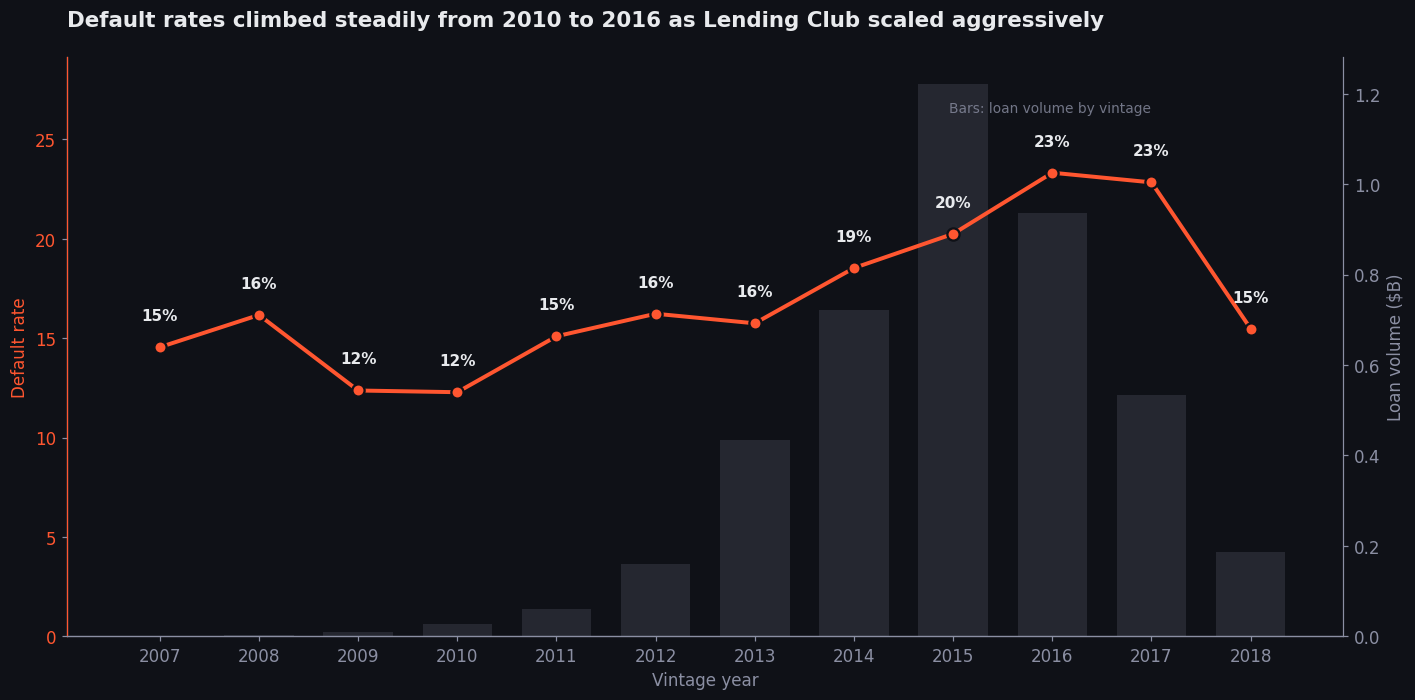


Vintage breakdown:

 issue_year default_rate  loans         volume
       2007        14.5%     55       $486,825
       2008        16.2%    334     $3,111,075
       2009        12.4%  1,027    $10,036,500
       2010        12.3%  2,557    $26,682,400
       2011        15.1%  4,942    $59,777,600
       2012        16.2% 11,855   $159,421,925
       2013        15.7% 29,630   $435,074,800
       2014        18.5% 49,413   $721,344,025
       2015        20.3% 83,120 $1,221,132,125
       2016        23.3% 64,616   $936,633,500
       2017        22.8% 37,170   $533,388,675
       2018        15.5% 12,580   $185,775,600


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Default rate by vintage year (year of loan origination)
# ─────────────────────────────────────────────────────────────────────────────

# Parse issue_d into a proper datetime, then extract the year
terminal['issue_dt']   = pd.to_datetime(terminal['issue_d'], format='%b-%Y')
terminal['issue_year'] = terminal['issue_dt'].dt.year

vintage = (
    terminal.groupby('issue_year')
            .agg(default_rate=('default', 'mean'),
                 loans=('default', 'size'),
                 volume=('loan_amnt', 'sum'))
            .reset_index()
)

fig, ax1 = plt.subplots(figsize=(13, 6.5))
ax2 = ax1.twinx()

# ─── BARS: loan volume by year (background context) ─────────────────────────
bar_color = PALETTE['muted']
bars = ax2.bar(
    vintage['issue_year'],
    vintage['volume'] / 1e9,
    color=bar_color,
    alpha=0.18,
    width=0.7,
    edgecolor='none',
    zorder=1,
)
ax2.set_ylabel('Loan volume ($B)', color=PALETTE['muted'])
ax2.tick_params(axis='y', labelcolor=PALETTE['muted'])
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(PALETTE['muted'])
ax2.spines['top'].set_visible(False)

# ─── LINE: default rate (foreground story) ──────────────────────────────────
ax1.plot(
    vintage['issue_year'],
    vintage['default_rate'] * 100,
    color=PALETTE['danger'],
    linewidth=2.6,
    marker='o',
    markersize=8,
    markerfacecolor=PALETTE['danger'],
    markeredgecolor=PALETTE['bg'],
    markeredgewidth=1.5,
    zorder=3,
)

# Value labels above each marker
for x, y in zip(vintage['issue_year'], vintage['default_rate'] * 100):
    ax1.text(
        x, y + 1.2, f'{y:.0f}%',
        ha='center', va='bottom',
        color=PALETTE['text'], fontsize=10, fontweight='600',
    )

ax1.set_xlabel('Vintage year', color=PALETTE['muted'])
ax1.set_ylabel('Default rate', color=PALETTE['danger'])
ax1.tick_params(axis='y', labelcolor=PALETTE['danger'])
ax1.tick_params(axis='x', labelcolor=PALETTE['muted'])
ax1.set_xticks(vintage['issue_year'])
ax1.set_ylim(0, vintage['default_rate'].max() * 100 * 1.25)
ax1.spines['left'].set_color(PALETTE['danger'])
ax1.spines['bottom'].set_color(PALETTE['muted'])
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.set_title(
    'Default rates climbed steadily from 2010 to 2016 as Lending Club scaled aggressively',
    loc='left', color=PALETTE['text'], pad=20,
)

# Subtle annotation for the volume bars
ax2.text(
    vintage['issue_year'].iloc[-2], vintage['volume'].max() / 1e9 * 0.95,
    'Bars: loan volume by vintage',
    color=PALETTE['muted'], fontsize=9, ha='right', alpha=0.8,
)

plt.tight_layout()
plt.savefig('outputs/05_default_by_vintage.png', dpi=160, bbox_inches='tight')
plt.show()

# ─── SUPPORTING TABLE ───────────────────────────────────────────────────────
print('\nVintage breakdown:\n')
print(
    vintage.assign(
        default_rate=lambda d: (d['default_rate'] * 100).round(1).astype(str) + '%',
        loans=lambda d: d['loans'].map('{:,}'.format),
        volume=lambda d: d['volume'].map('${:,.0f}'.format),
    ).to_string(index=False)
)

> **Three observations from the vintage chart:**
>
> 1. **Late-cycle loosening is visible.** From 2012 to 2016, loan volume grew nearly 3x ($0.4B → $1.2B), but the default rate also climbed from 16% to 23%. As Lending Club scaled, standards loosened — exactly the pattern that defines a late-cycle credit cycle.
>
> 2. **2010–2011 are the safest cohorts.** Both years sit around 12% default rate. Borrowers who took loans in the immediate post-crisis window were a self-selected, conservative population, and the platform was lending small.
>
> 3. **The 2018 dip is misleading.** It looks like default rates dropped sharply — but many 2018 loans haven't matured yet. They're still labeled `Current` in the data, not `Charged Off`. The model in notebook 04 will need to handle this maturity bias when training.
>
> The 2015–2017 cohorts produced the most defaults in absolute terms, both because default rates were highest and because volume was highest. That's where any model gets the most leverage.

## 6. Borrower profile: income, DTI, and loan size

The grade system uses FICO score and credit history as core inputs. But three other borrower attributes are sitting right there in the data — and the grade only partially incorporates them:

| Attribute | What it tells us |
|---|---|
| `annual_inc` | Annual income — capacity to pay |
| `dti` | Debt-to-income ratio — how leveraged the borrower already is |
| `loan_amnt` | Loan size — exposure if the loan defaults |

The chart below splits each of these three variables into bands and plots default rate inside each band. The shape of these curves tells us which features carry the most signal.

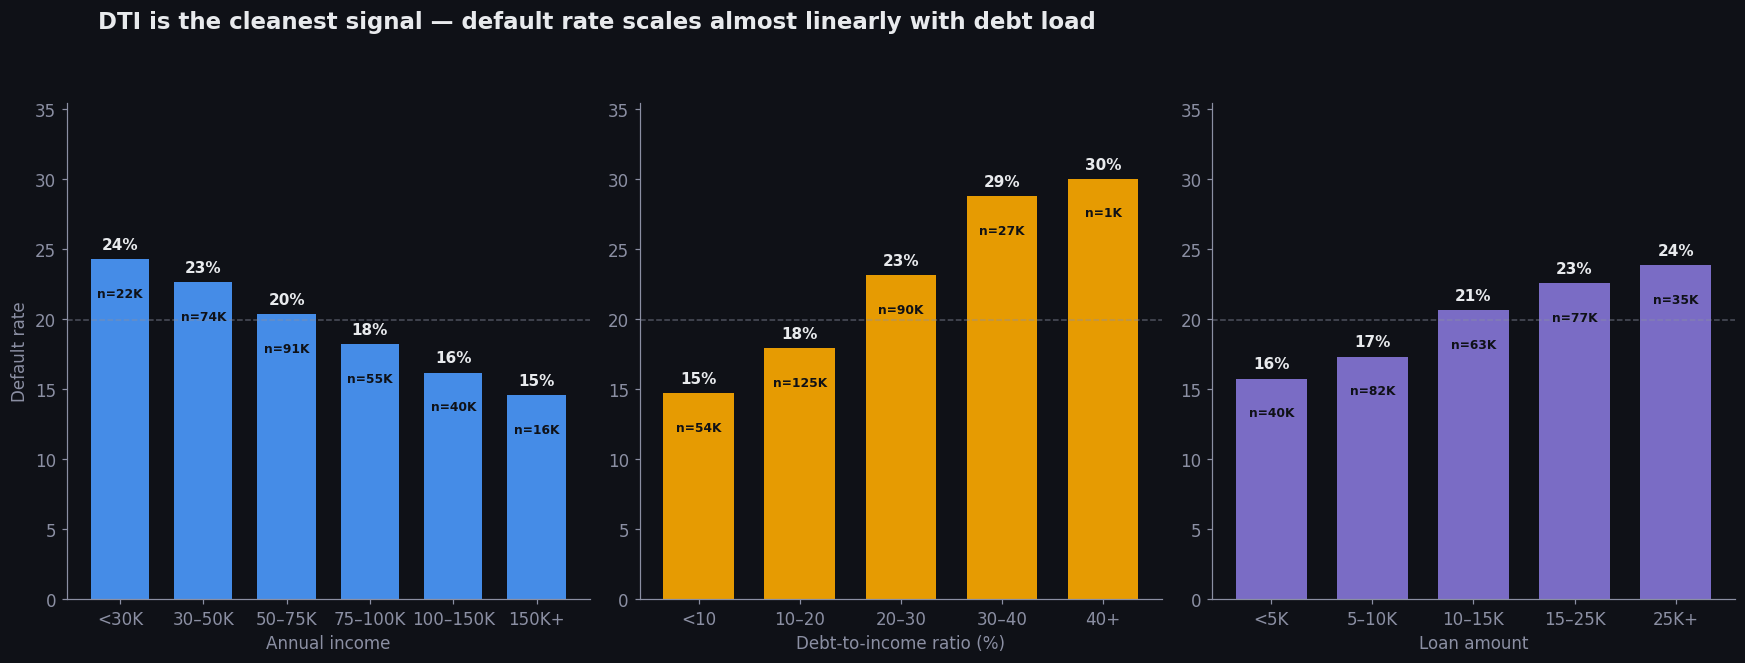

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Default rate by income, DTI, and loan amount bands
# ─────────────────────────────────────────────────────────────────────────────

# Build the three banded views
def banded_default_rate(df, col, bins, labels):
    """Cut a numeric column into bins, then compute default rate per bin."""
    binned = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
    out = (
        df.assign(_band=binned)
          .groupby('_band', observed=True)['default']
          .agg(['mean', 'count'])
          .reset_index()
          .rename(columns={'_band': 'band'})
    )
    return out

income_bins   = [0, 30_000, 50_000, 75_000, 100_000, 150_000, np.inf]
income_labels = ['<30K', '30–50K', '50–75K', '75–100K', '100–150K', '150K+']

dti_bins   = [-1, 10, 20, 30, 40, np.inf]
dti_labels = ['<10', '10–20', '20–30', '30–40', '40+']

amnt_bins   = [0, 5_000, 10_000, 15_000, 25_000, 40_000]
amnt_labels = ['<5K', '5–10K', '10–15K', '15–25K', '25K+']

income_stats = banded_default_rate(terminal, 'annual_inc', income_bins, income_labels)
dti_stats    = banded_default_rate(terminal[terminal['dti'].between(0, 60)], 'dti', dti_bins, dti_labels)
amnt_stats   = banded_default_rate(terminal, 'loan_amnt', amnt_bins, amnt_labels)

# ─── PLOT: three side-by-side bar charts ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

panels = [
    (axes[0], income_stats, 'Annual income',           PALETTE['primary']),
    (axes[1], dti_stats,    'Debt-to-income ratio (%)', PALETTE['warn']),
    (axes[2], amnt_stats,   'Loan amount',              PALETTE['accent']),
]

overall_rate = terminal['default'].mean()

for ax, stats, xlabel, color in panels:
    bars = ax.bar(
        stats['band'].astype(str),
        stats['mean'] * 100,
        color=color,
        edgecolor='none',
        width=0.7,
        alpha=0.9,
    )
    for bar, rate, n in zip(bars, stats['mean'], stats['count']):
        # Default-rate label above each bar
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{rate:.0%}',
            ha='center', va='bottom',
            color=PALETTE['text'], fontsize=10, fontweight='600',
        )
        # Sample-size label inside the top of each bar
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 2,
            f'n={n/1000:.0f}K' if n >= 1000 else f'n={n}',
            ha='center', va='top',
            color=PALETTE['bg'], fontsize=8, fontweight='600',
        )

    ax.axhline(y=overall_rate * 100, color=PALETTE['muted'],
               linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel(xlabel, color=PALETTE['muted'])
    ax.set_ylabel('Default rate', color=PALETTE['muted']) if ax is axes[0] else None
    ax.set_ylim(0, max(s['mean'].max() for _, s, _, _ in panels) * 100 * 1.18)
    ax.spines['left'].set_color(PALETTE['muted'])
    ax.spines['bottom'].set_color(PALETTE['muted'])
    ax.tick_params(colors=PALETTE['muted'])

fig.suptitle(
    'DTI is the cleanest signal — default rate scales almost linearly with debt load',
    x=0.06, y=1.0, ha='left',
    color=PALETTE['text'], fontsize=15, fontweight='bold',
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('outputs/06_borrower_profile.png', dpi=160, bbox_inches='tight')
plt.show()

> **Three observations from the borrower profile:**
>
> 1. **DTI is the cleanest signal in the dataset.** Default rate doubles from 15% (DTI under 10) to 30% (DTI over 40). That's a smoother, steeper relationship than either income or loan size — and it's the kind of monotonic curve a model can lean on heavily.
>
> 2. **Income matters but less than expected.** The lowest income band (<$30K) defaults at 24%, the highest (>$150K) at 15%. A 9-point spread is meaningful, but smaller than DTI's 15-point spread. Income matters; what you do with that income matters more.
>
> 3. **Bigger loans default more — even though grade should already account for this.** The 25K+ band defaults at 24%, the under-5K band at 16%. Loan size carries residual risk signal that the grade doesn't fully capture.
>
> Together these point to **DTI as the single most predictive numeric feature** in the dataset. Notebook 04 will confirm this with feature importance scores from the trained models.

## 7. The mispricing finding: same grade, different risk

Each section so far surfaced one variable at a time. This section combines them.

Lending Club's grade-based pricing means every Grade C loan gets roughly the same interest rate. But sections 3, 4, and 6 showed that purpose, geography, and DTI all carry meaningful additional signal. So *within* a single grade, default rates should vary along those other dimensions — and the borrowers paying the same interest rate should actually be very different risks.

The heatmap below makes this concrete. Rows are loan grades. Columns are loan purposes. Each cell shows the default rate for that grade-purpose combination. If the grade fully captured risk, every cell in a row would be the same shade. It isn't.

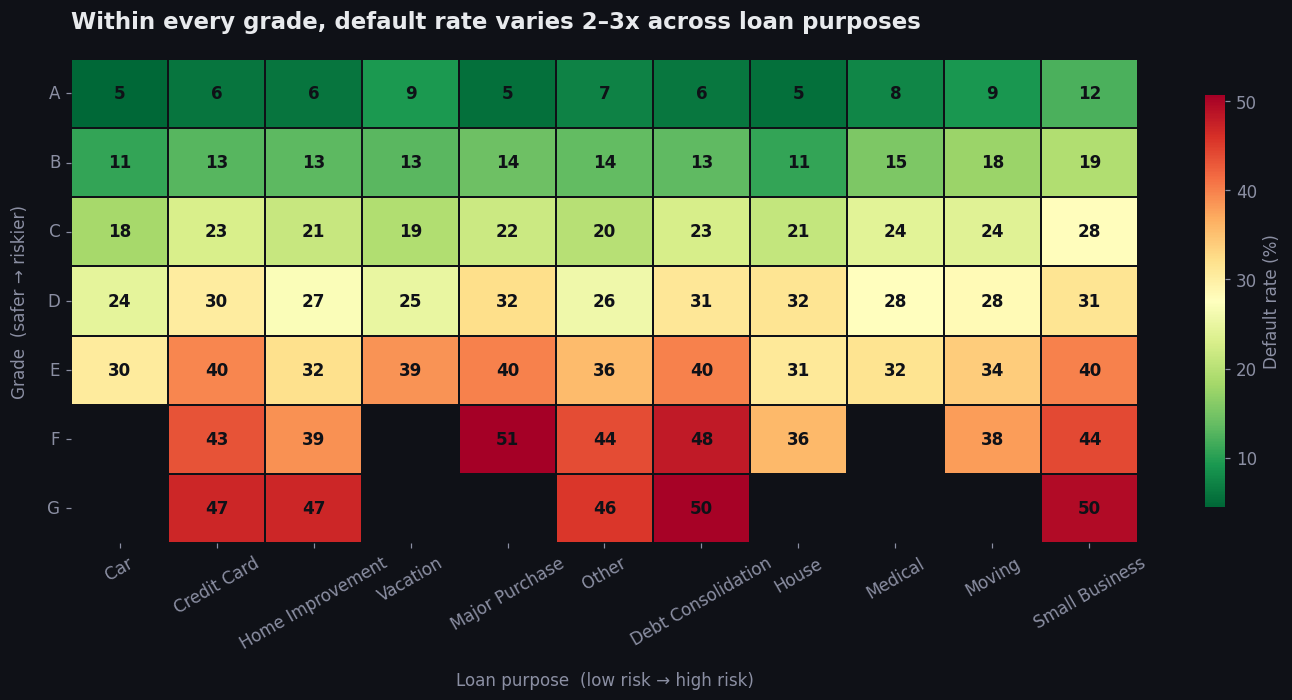

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Mispricing heatmap: default rate by grade × purpose
# ─────────────────────────────────────────────────────────────────────────────

# Keep major purposes only (1K+ loans) for readability
major_purposes = (
    terminal['purpose'].value_counts()
                       .loc[lambda s: s >= 1_000]
                       .index.tolist()
)

heatmap_df = (
    terminal[terminal['purpose'].isin(major_purposes)]
        .groupby(['grade', 'purpose'])['default']
        .agg(['mean', 'count'])
        .reset_index()
)

rate_pivot  = heatmap_df.pivot(index='grade', columns='purpose', values='mean')
count_pivot = heatmap_df.pivot(index='grade', columns='purpose', values='count')

purpose_order = (
    terminal[terminal['purpose'].isin(major_purposes)]
        .groupby('purpose')['default'].mean()
        .sort_values()
        .index.tolist()
)
rate_pivot  = rate_pivot[purpose_order]
count_pivot = count_pivot[purpose_order]

mask = count_pivot < 100

pretty_cols = [c.replace('_', ' ').title() for c in rate_pivot.columns]
rate_pivot.columns = pretty_cols

fig, ax = plt.subplots(figsize=(13, 6.5))

sns.heatmap(
    rate_pivot * 100,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Default rate (%)', 'shrink': 0.85},
    linewidths=1.2,
    linecolor=PALETTE['bg'],
    mask=mask.values,
    annot_kws={'fontsize': 11, 'fontweight': '600', 'color': PALETTE['bg']},
    ax=ax,
)

ax.set_xlabel('Loan purpose  (low risk → high risk)', color=PALETTE['muted'], labelpad=12)
ax.set_ylabel('Grade  (safer → riskier)', color=PALETTE['muted'], labelpad=12)
ax.set_title(
    'Within every grade, default rate varies 2–3x across loan purposes',
    loc='left', color=PALETTE['text'], pad=20, fontsize=15, fontweight='bold',
)
ax.tick_params(axis='x', rotation=30, labelcolor=PALETTE['muted'])
ax.tick_params(axis='y', rotation=0, labelcolor=PALETTE['muted'])

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(PALETTE['muted'])
cbar.ax.tick_params(colors=PALETTE['muted'])

plt.tight_layout()
plt.savefig('outputs/07_mispricing_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

> **The mispricing pattern, made concrete:**
>
> 1. **Grade A — the safest tier — already shows 2.4x risk variance by purpose.** A Grade A car loan defaults at 5%, a Grade A small-business loan at 12%. Both borrowers pay roughly the same interest rate. The grade system stops working at the very top of the credit ladder.
>
> > 2. **Small business loans are systematically underpriced at every grade.** The rightmost column is the darkest red in every row from A through F (Grade G is masked due to small sample). Borrowers using loans for business purposes default substantially more than the grade implies — yet pay no premium for the additional risk.
>
> 3. **The mispricing is biggest where volume is biggest.** Grades B and C hold the bulk of Lending Club's loan volume, and within those grades the spread between safest and riskiest purpose is 8–10 percentage points. That spread is the gap a model can monetize.
>
> Sections 2 through 6 each surfaced a piece of this. Section 7 stitches them together: **the grade is a useful coarse signal, but it leaves real, large, predictable risk variance on the table.** That gap is the entire reason a model is worth building.

## 8. Missing value audit and column-drop justification

The dataset has 151 columns. Most aren't useful for our analysis or for the model in notebook 04. This section audits which columns are sparse and which carry data leakage, and produces a clean column shortlist.

Three categories of columns get dropped:

| Category | Reason | Examples |
|---|---|---|
| **Sparsely populated** | More than 50% missing across the sample | `mths_since_last_record`, most `sec_app_*` fields |
| **Data leakage** | Only known *after* default — using these would be cheating | `recoveries`, `total_rec_prncp`, `last_pymnt_*` |
| **Identifiers and free text** | No predictive signal | `id`, `member_id`, `url`, `desc`, `emp_title` |

Important: this analysis runs on the full sample (`df`), not just terminal loans. We want to understand the dataset as a whole before filtering for modeling in notebook 03.

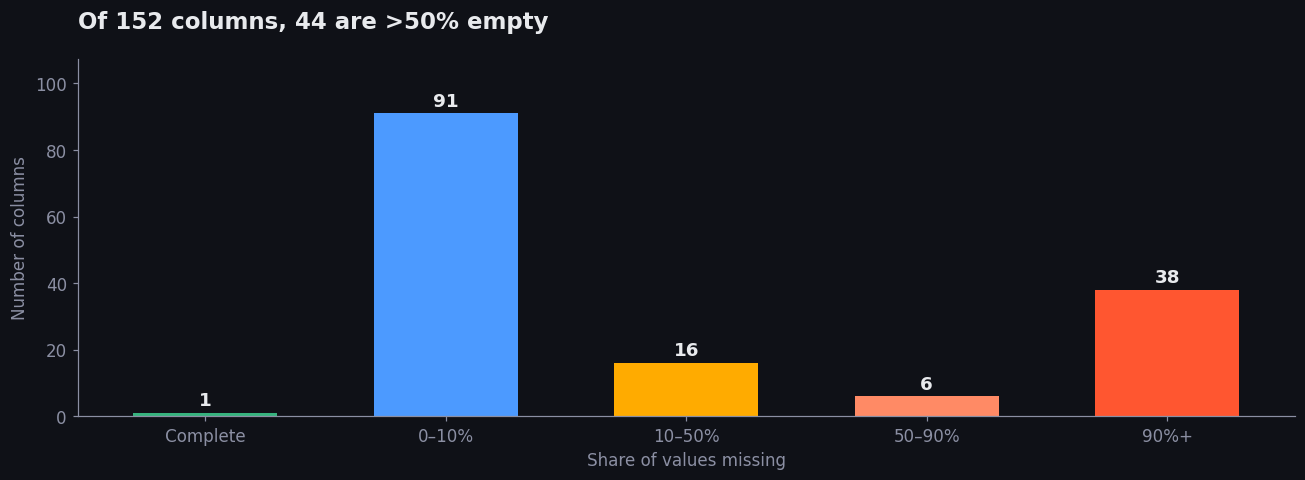


Top 20 sparsest columns:

                                    column missing_pct tier
                                 member_id      100.0% 90%+
orig_projected_additional_accrued_interest       99.6% 90%+
                      hardship_loan_status       99.5% 90%+
                             hardship_type       99.5% 90%+
                           hardship_reason       99.5% 90%+
                           hardship_status       99.5% 90%+
                             deferral_term       99.5% 90%+
                       hardship_start_date       99.5% 90%+
                         hardship_end_date       99.5% 90%+
                   payment_plan_start_date       99.5% 90%+
                              hardship_dpd       99.5% 90%+
                           hardship_amount       99.5% 90%+
            hardship_payoff_balance_amount       99.5% 90%+
              hardship_last_payment_amount       99.5% 90%+
                           hardship_length       99.5% 90%+
             

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Missing value audit across all 151 columns
# ─────────────────────────────────────────────────────────────────────────────
missing = (
    df.isna().sum()
      .div(len(df))
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={'index': 'column', 0: 'missing_pct'})
)

# Bucket each column into a missingness tier
def tier(pct):
    if pct >= 90: return '90%+'
    if pct >= 50: return '50–90%'
    if pct >= 10: return '10–50%'
    if pct >  0:  return '0–10%'
    return 'Complete'

missing['tier'] = missing['missing_pct'].apply(tier)

tier_counts = (
    missing['tier'].value_counts()
                   .reindex(['Complete', '0–10%', '10–50%', '50–90%', '90%+'])
                   .reset_index()
)
tier_counts.columns = ['tier', 'columns']

# ─── PLOT: stacked summary ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4.5))

tier_colors = {
    'Complete': PALETTE['success'],
    '0–10%':    PALETTE['primary'],
    '10–50%':   PALETTE['warn'],
    '50–90%':   '#ff8a65',
    '90%+':     PALETTE['danger'],
}

bars = ax.bar(
    tier_counts['tier'],
    tier_counts['columns'],
    color=[tier_colors[t] for t in tier_counts['tier']],
    edgecolor='none',
    width=0.6,
)

for bar, n in zip(bars, tier_counts['columns']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{n}',
        ha='center', va='bottom',
        color=PALETTE['text'], fontsize=12, fontweight='600',
    )

ax.set_xlabel('Share of values missing', color=PALETTE['muted'])
ax.set_ylabel('Number of columns', color=PALETTE['muted'])
ax.set_title(
    f'Of {df.shape[1]} columns, {(missing["missing_pct"] >= 50).sum()} are >50% empty',
    loc='left', color=PALETTE['text'], pad=20, fontsize=15, fontweight='bold',
)
ax.spines['left'].set_color(PALETTE['muted'])
ax.spines['bottom'].set_color(PALETTE['muted'])
ax.tick_params(colors=PALETTE['muted'])
ax.set_ylim(0, tier_counts['columns'].max() * 1.18)

plt.tight_layout()
plt.savefig('outputs/08_missing_tiers.png', dpi=160, bbox_inches='tight')
plt.show()

# ─── SUPPORTING TABLE: top 20 sparsest columns ──────────────────────────────
print('\nTop 20 sparsest columns:\n')
top20 = missing.head(20).copy()
top20['missing_pct'] = top20['missing_pct'].round(1).astype(str) + '%'
print(top20.to_string(index=False))

## 8b. Column drop list — codified

The drop list below is what notebook 03 will use to clean the dataset before modeling. Three groups, each with a one-line reason. Total kept: roughly 50 columns out of the original 151.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Codified column drop list with justification
# ─────────────────────────────────────────────────────────────────────────────

# (1) Sparsely populated — anything >50% missing
sparse_cols = missing.loc[missing['missing_pct'] > 50, 'column'].tolist()

# (2) Data leakage — these are only populated AFTER default, so the model would
#     be predicting an outcome using data that was caused BY that outcome
leakage_cols = [
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'out_prncp', 'out_prncp_inv',
    'collections_12_mths_ex_med',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
]

# (3) Identifiers, free text, and admin fields with no predictive value
junk_cols = [
    'id', 'member_id',
    'url', 'desc', 'title',
    'emp_title',
    'zip_code',
    'policy_code', 'pymnt_plan',
    'hardship_flag',
]

# Build the master drop list, then trim to columns that actually exist
drop_set = set(sparse_cols) | set(leakage_cols) | set(junk_cols)
drop_list = [c for c in drop_set if c in df.columns]

kept_cols = [c for c in df.columns if c not in drop_list]

# ─── SUMMARY ────────────────────────────────────────────────────────────────
print(f"Original columns       : {df.shape[1]}")
print(f"  Dropped — sparse     : {len([c for c in sparse_cols if c in df.columns])}")
print(f"  Dropped — leakage    : {len([c for c in leakage_cols if c in df.columns])}")
print(f"  Dropped — junk       : {len([c for c in junk_cols if c in df.columns])}")
print(f"Total dropped          : {len(drop_list)}")
print(f"Kept for modeling      : {len(kept_cols)}")

# Save the drop list to outputs so notebook 03 can import it cleanly
import json
with open('outputs/columns_to_drop.json', 'w') as f:
    json.dump(
        {
            'sparse':  [c for c in sparse_cols  if c in df.columns],
            'leakage': [c for c in leakage_cols if c in df.columns],
            'junk':    [c for c in junk_cols   if c in df.columns],
        },
        f, indent=2,
    )
print("\nDrop list saved to: outputs/columns_to_drop.json")

Original columns       : 152
  Dropped — sparse     : 44
  Dropped — leakage    : 23
  Dropped — junk       : 10
Total dropped          : 68
Kept for modeling      : 84

Drop list saved to: outputs/columns_to_drop.json


## 9. Handoff to notebook 03

Section 7 made the central finding concrete: Lending Club's grade-based pricing leaves systematic risk variance unexplained. Within every grade, default rates vary 2–3x by purpose. Geography, DTI, and vintage all add further independent signal that the grade ignores.

That gap is what the model in notebook 04 will try to close.

### What this notebook produced

| Output | Used by |
|---|---|
| `outputs/01_loan_status_distribution.png` | README, business-context narrative |
| `outputs/02_default_by_grade.png` | README, mispricing thesis |
| `outputs/03_default_by_purpose.png` | Power BI dashboard, page 2 |
| `outputs/04_default_by_state.png` | Power BI dashboard, page 2 |
| `outputs/05_default_by_vintage.png` | README, vintage analysis section |
| `outputs/06_borrower_profile.png` | Notebook 04, feature-importance comparison |
| `outputs/07_mispricing_heatmap.png` | **The headline chart for the LinkedIn post** |
| `outputs/08_missing_tiers.png` | Notebook 03, data cleaning context |
| `outputs/columns_to_drop.json` | Notebook 03, programmatic column filter |

### Headline findings to carry forward

1. Default rate ramps cleanly 6% → 49% across grades A–G — the grade system is directionally correct
2. Within-grade variance is wide — a Grade A small-business loan defaults at 12% while a Grade A car loan defaults at 5%, both at the same interest rate
3. Small business loans default at ~2x the portfolio average and are systematically underpriced at every grade
4. DTI is the cleanest numeric signal: default rate doubles from 15% (DTI<10) to 30% (DTI>40)
5. Late-cycle loosening is visible — 2015–2017 cohorts default at 23% vs 12% for 2010–2011 cohorts
6. Geography matters — Mississippi defaults at 27.5%, Oregon at 13.6%

### Next: notebook 03 — feature engineering

Notebook 03 picks up here, applies the column drop list, engineers the risk features the model will use (DTI tiers, FICO bands, credit history flags, income-to-loan ratios), and produces a clean train/test split ready for notebook 04.